Crop Yield Prediction - Regression Analysis

End-to-End Machine Learning Project

Dataset: FAO Crop Yield Dataset  
Task: Regression (Crop Yield Prediction)  
Aligned UNSDG: Goal 2 - Zero Hunger  

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Setup and Data Loading

In [64]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)
from sklearn.feature_selection import SelectKBest, f_regression, RFE
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

1.1 Load Dataset

Dataset Information:
- Source: Food and Agriculture Organization (FAO) of the United Nations
- Created by: FAO Statistics Division (FAOSTAT)
- Access: Public dataset available from FAOSTAT database
- Purpose: Track crop yield trends across countries and years
- Time Period: 1961-2016 (approximately 55 years)
- UNSDG Alignment:
  - Goal 2 (Zero Hunger): Understanding and predicting crop yields is essential for food security planning
  - Goal 13 (Climate Action): Helps monitor agricultural productivity changes due to climate factors

In [65]:
# Load the dataset
# Upload your yield.csv file to Colab first
# Use: from google.colab import files; uploaded = files.upload()

df = pd.read_csv('/content/drive/MyDrive/Concepts and Technology of AI/Final Assessment/yield.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (56717, 12)

First 5 rows:


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


In [66]:
# Dataset information
print("Dataset Information:")
df.info()
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56717 entries, 0 to 56716
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Domain Code   56717 non-null  object
 1   Domain        56717 non-null  object
 2   Area Code     56717 non-null  int64 
 3   Area          56717 non-null  object
 4   Element Code  56717 non-null  int64 
 5   Element       56717 non-null  object
 6   Item Code     56717 non-null  int64 
 7   Item          56717 non-null  object
 8   Year Code     56717 non-null  int64 
 9   Year          56717 non-null  int64 
 10  Unit          56717 non-null  object
 11  Value         56717 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 5.2+ MB

Column Names:
['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element', 'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value']


### 1.3 Research Questions

This dataset can answer the following meaningful questions:

1. Can we predict crop yields based on country, crop type, and temporal trends?
2. How have crop yields changed over time across different countries and crops?
3. Which factors (country, crop type, year) are most influential in determining yield?

2. Exploratory Data Analysis (EDA)

2.1 Data Quality Assessment

In [67]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nPercentage of Missing Values:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values:
Domain Code     0
Domain          0
Area Code       0
Area            0
Element Code    0
Element         0
Item Code       0
Item            0
Year Code       0
Year            0
Unit            0
Value           0
dtype: int64

Percentage of Missing Values:
Domain Code     0.0
Domain          0.0
Area Code       0.0
Area            0.0
Element Code    0.0
Element         0.0
Item Code       0.0
Item            0.0
Year Code       0.0
Year            0.0
Unit            0.0
Value           0.0
dtype: float64


In [68]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [69]:
# Statistical summary
print("Statistical Summary of Numeric Columns:")
df.describe()

Statistical Summary of Numeric Columns:


,Area Code,Element Code,Item Code,Year Code,Year,Value
count,56717.000000,56717.0,56717.000000,56717.000000,56717.000000,56717.000000
mean,125.650422,5419.0,111.611651,1989.669570,1989.669570,62094.660084
std,75.120195,0.0,101.278435,16.133198,16.133198,67835.932856
min,1.000000,5419.0,15.000000,1961.000000,1961.000000,0.000000
25%,58.000000,5419.0,56.000000,1976.000000,1976.000000,15680.000000
50%,122.000000,5419.0,116.000000,1991.000000,1991.000000,36744.000000
75%,184.000000,5419.0,125.000000,2004.000000,2004.000000,86213.000000
max,351.000000,5419.0,489.000000,2016.000000,2016.000000,1000000.000000


In [70]:
# Check unique values in categorical columns
print("Unique Values in Categorical Columns:")
print(f"Number of Countries: {df['Area'].nunique()}")
print(f"Number of Crops: {df['Item'].nunique()}")
print(f"Year Range: {df['Year'].min()} - {df['Year'].max()}")
print(f"\nCrop Types:")
print(df['Item'].value_counts())

Unique Values in Categorical Columns:
Number of Countries: 212
Number of Crops: 10
Year Range: 1961 - 2016

Crop Types:
Item
Maize                   8631
Potatoes                7876
Rice, paddy             6469
Sweet potatoes          6356
Wheat                   6160
Cassava                 5718
Sorghum                 5511
Soybeans                4192
Yams                    3150
Plantains and others    2654
Name: count, dtype: int64


2.2 Data Cleaning and Preprocessing

In [71]:
# Drop unnecessary columns (redundant code columns and constant values)
columns_to_drop = ['Domain Code', 'Domain', 'Element Code', 'Element',
                   'Item Code', 'Year Code', 'Area Code', 'Unit']
df_clean = df.drop(columns=columns_to_drop)

print(f"Original shape: {df.shape}")
print(f"After dropping columns: {df_clean.shape}")
print(f"\nRemaining columns: {df_clean.columns.tolist()}")

Original shape: (56717, 12)
After dropping columns: (56717, 4)

Remaining columns: ['Area', 'Item', 'Year', 'Value']


In [72]:
# Check for missing values in Value column (target)
print(f"Missing values in Value (target): {df_clean['Value'].isnull().sum()}")

# Remove any rows with missing target values
df_clean = df_clean.dropna(subset=['Value'])
print(f"Shape after removing missing targets: {df_clean.shape}")

Missing values in Value (target): 0
Shape after removing missing targets: (56717, 4)


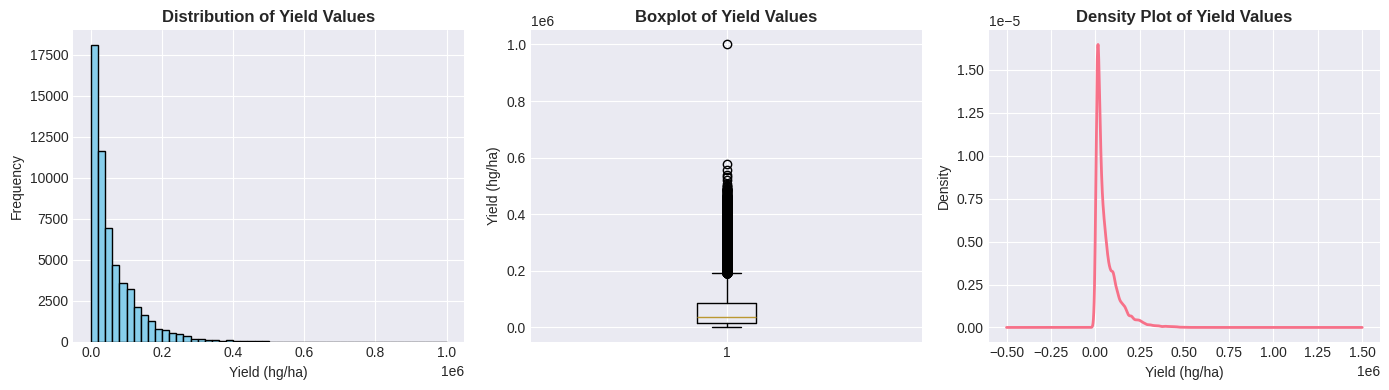


Yield Statistics:
Mean: 62094.66
Median: 36744.00
Std Dev: 67835.93
Min: 0.00
Max: 1000000.00


In [73]:
# Check for outliers in target variable
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.hist(df_clean['Value'], bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution of Yield Values', fontweight='bold')
plt.xlabel('Yield (hg/ha)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.boxplot(df_clean['Value'], vert=True)
plt.title('Boxplot of Yield Values', fontweight='bold')
plt.ylabel('Yield (hg/ha)')

plt.subplot(1, 3, 3)
df_clean['Value'].plot(kind='density', linewidth=2)
plt.title('Density Plot of Yield Values', fontweight='bold')
plt.xlabel('Yield (hg/ha)')

plt.tight_layout()
plt.show()

print(f"\nYield Statistics:")
print(f"Mean: {df_clean['Value'].mean():.2f}")
print(f"Median: {df_clean['Value'].median():.2f}")
print(f"Std Dev: {df_clean['Value'].std():.2f}")
print(f"Min: {df_clean['Value'].min():.2f}")
print(f"Max: {df_clean['Value'].max():.2f}")

2.3 Exploratory Visualizations

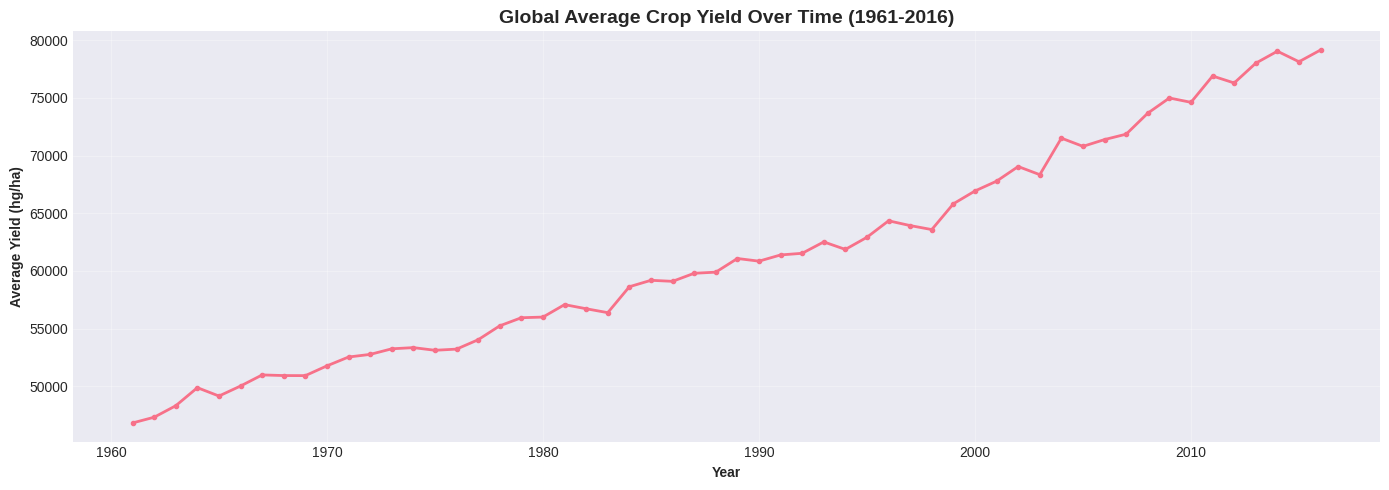

Insight: Global crop yields show a clear upward trend from 1961 to 2016, indicating improvements in agricultural practices, technology, and crop varieties.


In [74]:
# Yield trends over time
plt.figure(figsize=(14, 5))
yearly_avg = df_clean.groupby('Year')['Value'].mean()
plt.plot(yearly_avg.index, yearly_avg.values, linewidth=2, marker='o', markersize=3)
plt.title('Global Average Crop Yield Over Time (1961-2016)', fontweight='bold', fontsize=14)
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Average Yield (hg/ha)', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight: Global crop yields show a clear upward trend from 1961 to 2016, indicating improvements in agricultural practices, technology, and crop varieties.")

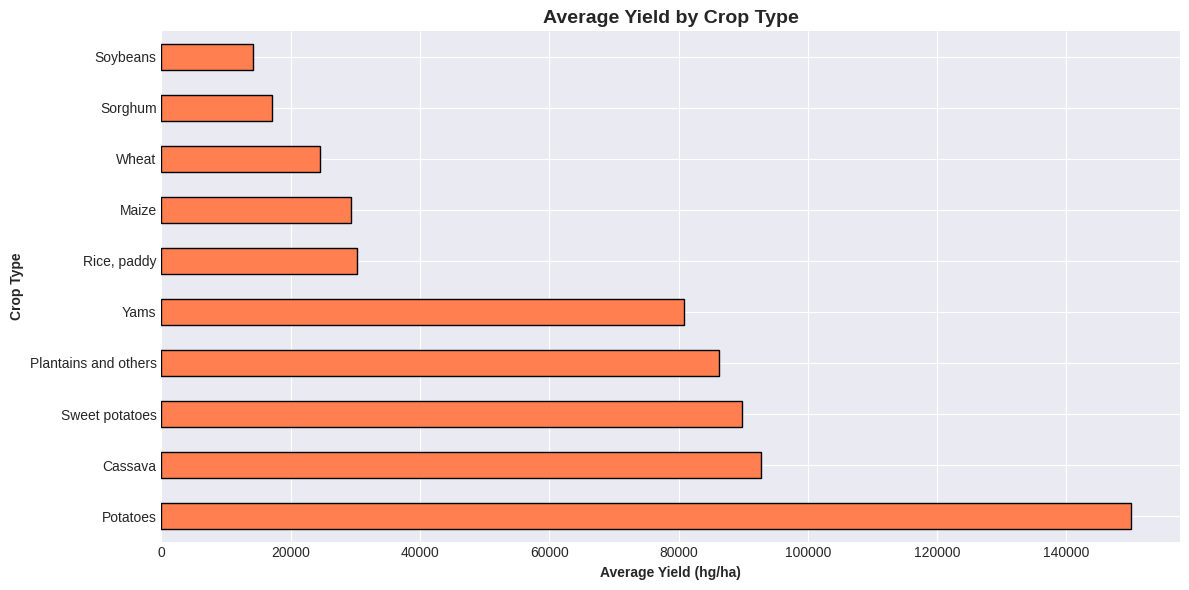


Top 5 Highest Yielding Crops:
Item
Potatoes                150083.237176
Cassava                  92768.762854
Sweet potatoes           89885.121460
Plantains and others     86282.765637
Yams                     80903.501587
Name: Value, dtype: float64

Insight: Different crops have vastly different yield potentials, with some crops producing significantly higher yields per hectare.


In [75]:
# Yield by crop type
plt.figure(figsize=(12, 6))
crop_avg = df_clean.groupby('Item')['Value'].mean().sort_values(ascending=False)
crop_avg.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Average Yield by Crop Type', fontweight='bold', fontsize=14)
plt.xlabel('Average Yield (hg/ha)', fontweight='bold')
plt.ylabel('Crop Type', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTop 5 Highest Yielding Crops:")
print(crop_avg.head())
print("\nInsight: Different crops have vastly different yield potentials, with some crops producing significantly higher yields per hectare.")

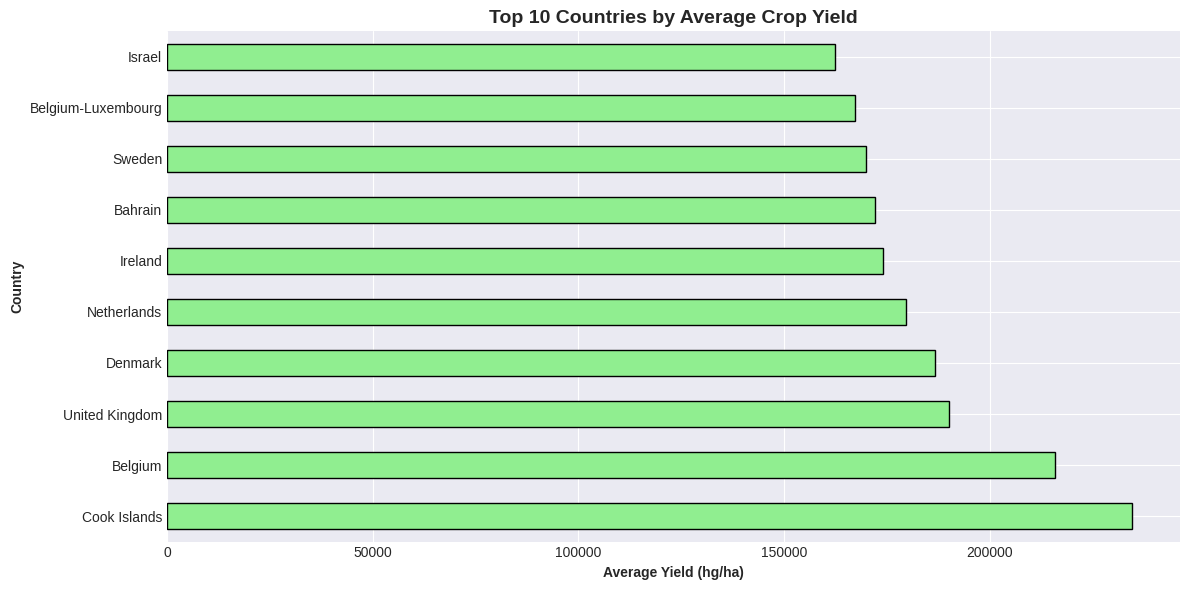


Insight: Agricultural productivity varies significantly across countries, influenced by climate, technology, and farming practices.


In [76]:
# Top 10 countries by average yield
plt.figure(figsize=(12, 6))
country_avg = df_clean.groupby('Area')['Value'].mean().sort_values(ascending=False).head(10)
country_avg.plot(kind='barh', color='lightgreen', edgecolor='black')
plt.title('Top 10 Countries by Average Crop Yield', fontweight='bold', fontsize=14)
plt.xlabel('Average Yield (hg/ha)', fontweight='bold')
plt.ylabel('Country', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInsight: Agricultural productivity varies significantly across countries, influenced by climate, technology, and farming practices.")

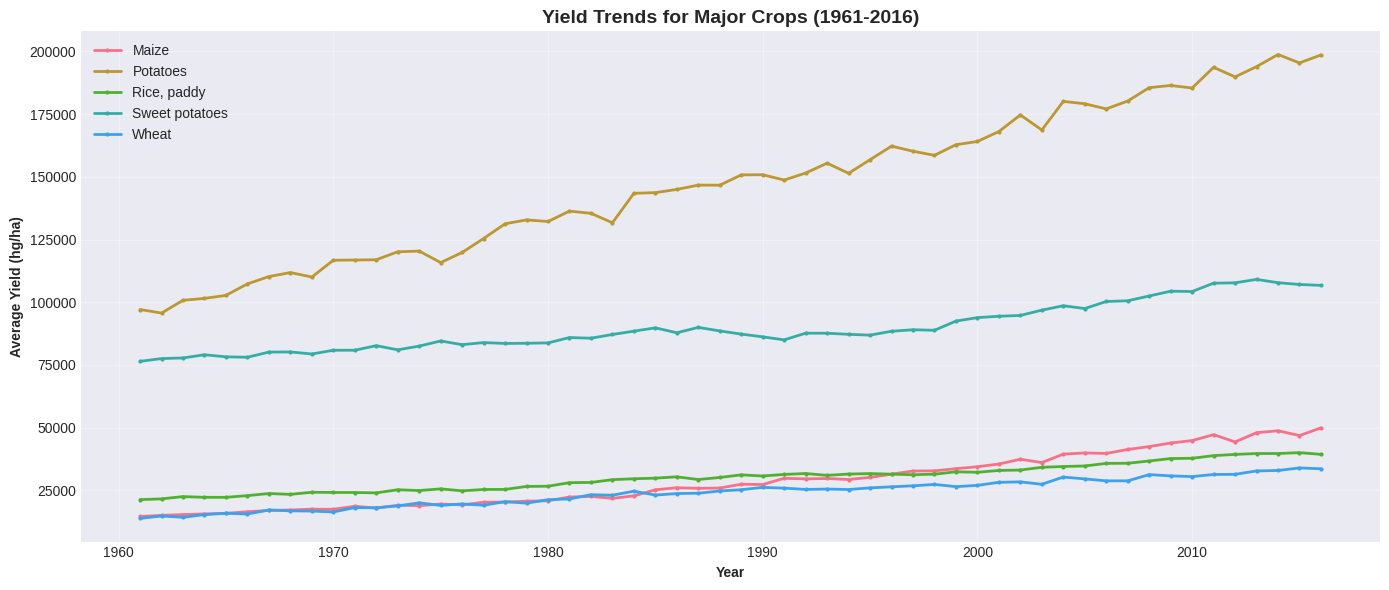

Insight: All major crops show increasing yield trends over time, though at different rates and with varying patterns.


In [77]:
# Yield trends for major crops
major_crops = df_clean['Item'].value_counts().head(5).index
plt.figure(figsize=(14, 6))

for crop in major_crops:
    crop_data = df_clean[df_clean['Item'] == crop].groupby('Year')['Value'].mean()
    plt.plot(crop_data.index, crop_data.values, marker='o', markersize=2, linewidth=2, label=crop)

plt.title('Yield Trends for Major Crops (1961-2016)', fontweight='bold', fontsize=14)
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Average Yield (hg/ha)', fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight: All major crops show increasing yield trends over time, though at different rates and with varying patterns.")

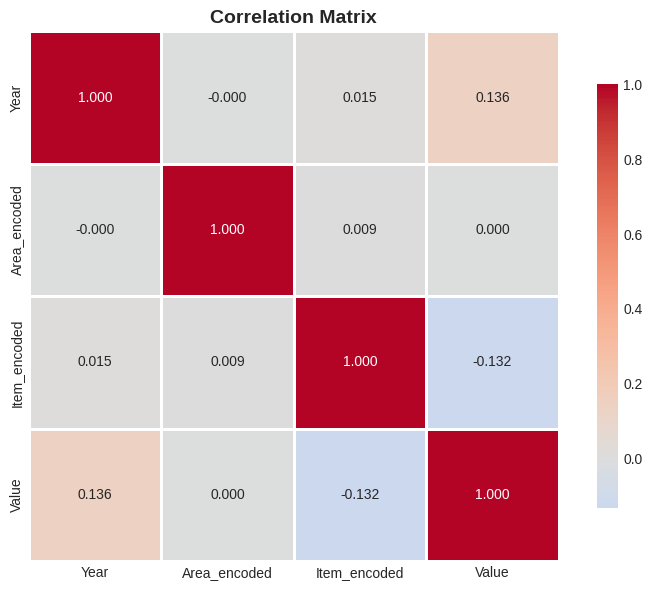


Correlation with Yield:
Value           1.000000
Year            0.136153
Area_encoded    0.000005
Item_encoded   -0.132445
Name: Value, dtype: float64


In [78]:
# Correlation analysis (after encoding categorical variables)
# Create numeric encoding for visualization
df_encoded = df_clean.copy()
le_area = LabelEncoder()
le_item = LabelEncoder()
df_encoded['Area_encoded'] = le_area.fit_transform(df_encoded['Area'])
df_encoded['Item_encoded'] = le_item.fit_transform(df_encoded['Item'])

plt.figure(figsize=(8, 6))
correlation = df_encoded[['Year', 'Area_encoded', 'Item_encoded', 'Value']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.3f')
plt.title('Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\nCorrelation with Yield:")
print(correlation['Value'].sort_values(ascending=False))

3. Feature Engineering and Preparation

In [79]:
# Create additional features
df_features = df_clean.copy()

# Time-based features
df_features['Years_Since_1961'] = df_features['Year'] - 1961
df_features['Decade'] = (df_features['Year'] // 10) * 10

# One-hot encoding for categorical variables
df_features = pd.get_dummies(df_features, columns=['Area', 'Item'], drop_first=True)

print(f"Shape after feature engineering: {df_features.shape}")
print(f"Number of features: {df_features.shape[1] - 1}")  # -1 for target column

Shape after feature engineering: (56717, 224)
Number of features: 223


In [80]:
# Separate features and target
X = df_features.drop('Value', axis=1)
y = df_features['Value']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget variable statistics:")
print(y.describe())

Features shape: (56717, 223)
Target shape: (56717,)

Target variable statistics:
count      56717.000000
mean       62094.660084
std        67835.932856
min            0.000000
25%        15680.000000
50%        36744.000000
75%        86213.000000
max      1000000.000000
Name: Value, dtype: float64


In [81]:
# Train-test split (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining target statistics:")
print(y_train.describe())
print(f"\nTest target statistics:")
print(y_test.describe())

Training set size: 45373 samples
Test set size: 11344 samples

Training target statistics:
count      45373.000000
mean       62132.970643
std        67806.656943
min            0.000000
25%        15684.000000
50%        36821.000000
75%        86146.000000
max      1000000.000000
Name: Value, dtype: float64

Test target statistics:
count     11344.000000
mean      61941.427980
std       67955.679404
min           0.000000
25%       15664.250000
50%       36548.000000
75%       86580.000000
max      540003.000000
Name: Value, dtype: float64


In [82]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Features have been standardized (mean=0, std=1)")

Features have been standardized (mean=0, std=1)


## 4. Build Neural Network Model for Regression

In [83]:
# Neural Network Architecture
print("Neural Network Configuration:")

print("Architecture: Multi-Layer Perceptron (MLP) Regressor")
print("Hidden Layers: 1 layer with 50 neurons (faster training)")
print("Activation Function: ReLU (Rectified Linear Unit)")
print("Output Layer: Linear (for regression)")
print("Loss Function: Mean Squared Error (MSE)")
print("Solver: Adam optimizer")
print("Max Iterations: 200")
print("Early Stopping: Enabled")

# Build faster MLP model
mlp = MLPRegressor(
    hidden_layer_sizes=(50,),   # simpler architecture
    activation='relu',
    solver='adam',
    max_iter=200,               # reduced iterations
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

# Train the model
print("\nTraining Neural Network...")
mlp.fit(X_train_scaled, y_train)
print("Training completed!")
print(f"Number of iterations: {mlp.n_iter_}")


Neural Network Configuration:
Architecture: Multi-Layer Perceptron (MLP) Regressor
Hidden Layers: 1 layer with 50 neurons (faster training)
Activation Function: ReLU (Rectified Linear Unit)
Output Layer: Linear (for regression)
Loss Function: Mean Squared Error (MSE)
Solver: Adam optimizer
Max Iterations: 200
Early Stopping: Enabled

Training Neural Network...
Training completed!
Number of iterations: 200


In [84]:
# Predictions
y_train_pred_mlp = mlp.predict(X_train_scaled)
y_test_pred_mlp = mlp.predict(X_test_scaled)

# Calculate metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n{dataset_name} Metrics:")
    print(f"  MSE:        {mse:.2f}")
    print(f"  RMSE:       {rmse:.2f}")
    print(f"  MAE:        {mae:.2f}")
    print(f"  R-squared:  {r2:.4f}")
    print(f"  MAPE:       {mape:.2f}%")

    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

# Evaluation
print("NEURAL NETWORK PERFORMANCE")

mlp_train_metrics = calculate_metrics(y_train, y_train_pred_mlp, "Training Set")
mlp_test_metrics = calculate_metrics(y_test, y_test_pred_mlp, "Test Set")

NEURAL NETWORK PERFORMANCE

Training Set Metrics:
  MSE:        1329290293.99
  RMSE:       36459.43
  MAE:        23671.00
  R-squared:  0.7109
  MAPE:       1143278065246524032.00%

Test Set Metrics:
  MSE:        1319915672.80
  RMSE:       36330.64
  MAE:        23461.38
  R-squared:  0.7142
  MAPE:       362923959193160576.00%


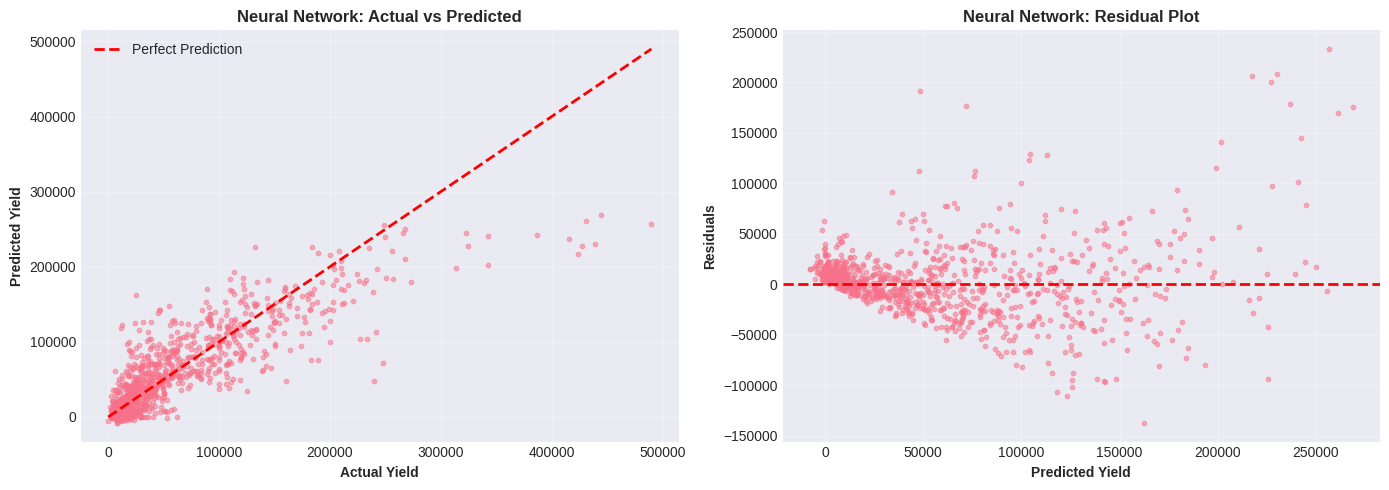

In [85]:
# Visualize Neural Network predictions (faster version with sampling)

# Ensure y_test_pred_mlp is defined, in case previous cell was skipped or reset
# This line is usually in the preceding cell (xJx4j_K-XiXe)
y_test_pred_mlp = mlp.predict(X_test_scaled)

# Sample up to 1000 points for faster plotting
sample_size = min(1000, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

y_test_sample = y_test.iloc[sample_indices]
y_pred_sample = y_test_pred_mlp[sample_indices]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Actual vs Predicted
axes[0].scatter(y_test_sample, y_pred_sample, alpha=0.5, s=10)
axes[0].plot([y_test_sample.min(), y_test_sample.max()],
             [y_test_sample.min(), y_test_sample.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Yield', fontweight='bold')
axes[0].set_ylabel('Predicted Yield', fontweight='bold')
axes[0].set_title('Neural Network: Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residual plot
residuals = y_test_sample - y_pred_sample
axes[1].scatter(y_pred_sample, residuals, alpha=0.5, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Yield', fontweight='bold')
axes[1].set_ylabel('Residuals', fontweight='bold')
axes[1].set_title('Neural Network: Residual Plot', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

5. Build Classical ML Models

5.1 Model 1: Linear Regression

In [86]:
# Build Linear Regression
print("Building Linear Regression Model...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
print("LINEAR REGRESSION PERFORMANCE")

lr_train_metrics = calculate_metrics(y_train, y_train_pred_lr, "Training Set")
lr_test_metrics = calculate_metrics(y_test, y_test_pred_lr, "Test Set")

Building Linear Regression Model...
LINEAR REGRESSION PERFORMANCE

Training Set Metrics:
  MSE:        1532450640.00
  RMSE:       39146.53
  MAE:        26651.28
  R-squared:  0.6667
  MAPE:       1539130044499891968.00%

Test Set Metrics:
  MSE:        1522364412.25
  RMSE:       39017.49
  MAE:        26516.88
  R-squared:  0.6703
  MAPE:       1193246118525520896.00%


5.2 Model 2: Random Forest Regressor

In [87]:
# Build Random Forest
print("Building Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Evaluation
print("RANDOM FOREST PERFORMANCE")

rf_train_metrics = calculate_metrics(y_train, y_train_pred_rf, "Training Set")
rf_test_metrics = calculate_metrics(y_test, y_test_pred_rf, "Test Set")

Building Random Forest Regressor...
RANDOM FOREST PERFORMANCE

Training Set Metrics:
  MSE:        24413052.71
  RMSE:       4940.96
  MAE:        1961.89
  R-squared:  0.9947
  MAPE:       450779423914958720.00%

Test Set Metrics:
  MSE:        159544362.21
  RMSE:       12631.09
  MAE:        5427.46
  R-squared:  0.9654
  MAPE:       895215878820902400.00%


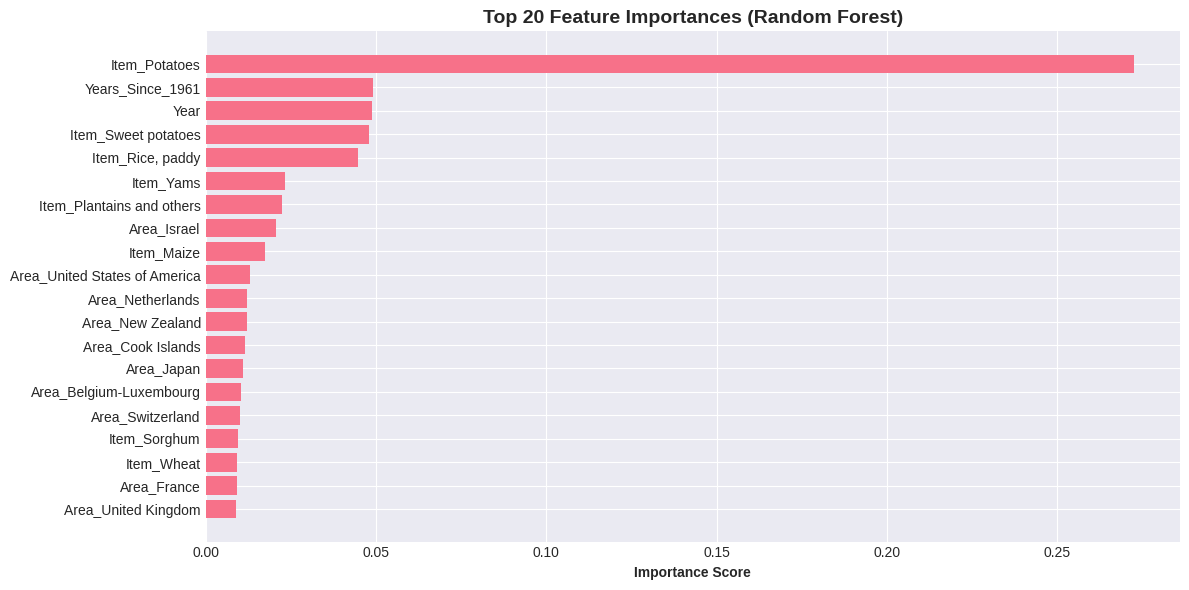


Top 15 Most Important Features:
                           feature  importance
216                  Item_Potatoes    0.272390
1                 Years_Since_1961    0.049163
0                             Year    0.048743
220            Item_Sweet potatoes    0.047953
217               Item_Rice, paddy    0.044747
222                      Item_Yams    0.023399
215      Item_Plantains and others    0.022458
98                     Area_Israel    0.020618
214                     Item_Maize    0.017482
203  Area_United States of America    0.013096
134               Area_Netherlands    0.012214
136               Area_New Zealand    0.012027
47               Area_Cook Islands    0.011438
101                     Area_Japan    0.011020
19         Area_Belgium-Luxembourg    0.010269


In [88]:
# Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(feature_importance['feature'].head(20), feature_importance['importance'].head(20))
plt.xlabel('Importance Score', fontweight='bold')
plt.title('Top 20 Feature Importances (Random Forest)', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15))

5.3 Initial Model Comparison

In [89]:
# Compare models
initial_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'Train RMSE': [
        lr_train_metrics['RMSE'],
        rf_train_metrics['RMSE']
    ],
    'Test RMSE': [
        lr_test_metrics['RMSE'],
        rf_test_metrics['RMSE']
    ],
    'Train R²': [
        lr_train_metrics['R2'],
        rf_train_metrics['R2']
    ],
    'Test R²': [
        lr_test_metrics['R2'],
        rf_test_metrics['R2']
    ],
    'Test MAE': [
        lr_test_metrics['MAE'],
        rf_test_metrics['MAE']
    ],
    'Test MAPE': [
        lr_test_metrics['MAPE'],
        rf_test_metrics['MAPE']
    ]
})

print("INITIAL MODEL COMPARISON (Before Optimization)")

print(initial_comparison.to_string(index=False))

# Determine best model
best_initial_idx = initial_comparison['Test R²'].idxmax()
best_initial = initial_comparison.loc[best_initial_idx, 'Model']
print(f"\n✓ Best performing model (based on R²): {best_initial}")

INITIAL MODEL COMPARISON (Before Optimization)
            Model   Train RMSE    Test RMSE  Train R²  Test R²     Test MAE    Test MAPE
Linear Regression 39146.527815 39017.488544  0.666688 0.670310 26516.876692 1.193246e+18
    Random Forest  4940.956659 12631.087135  0.994690 0.965448  5427.456631 8.952159e+17

✓ Best performing model (based on R²): Random Forest


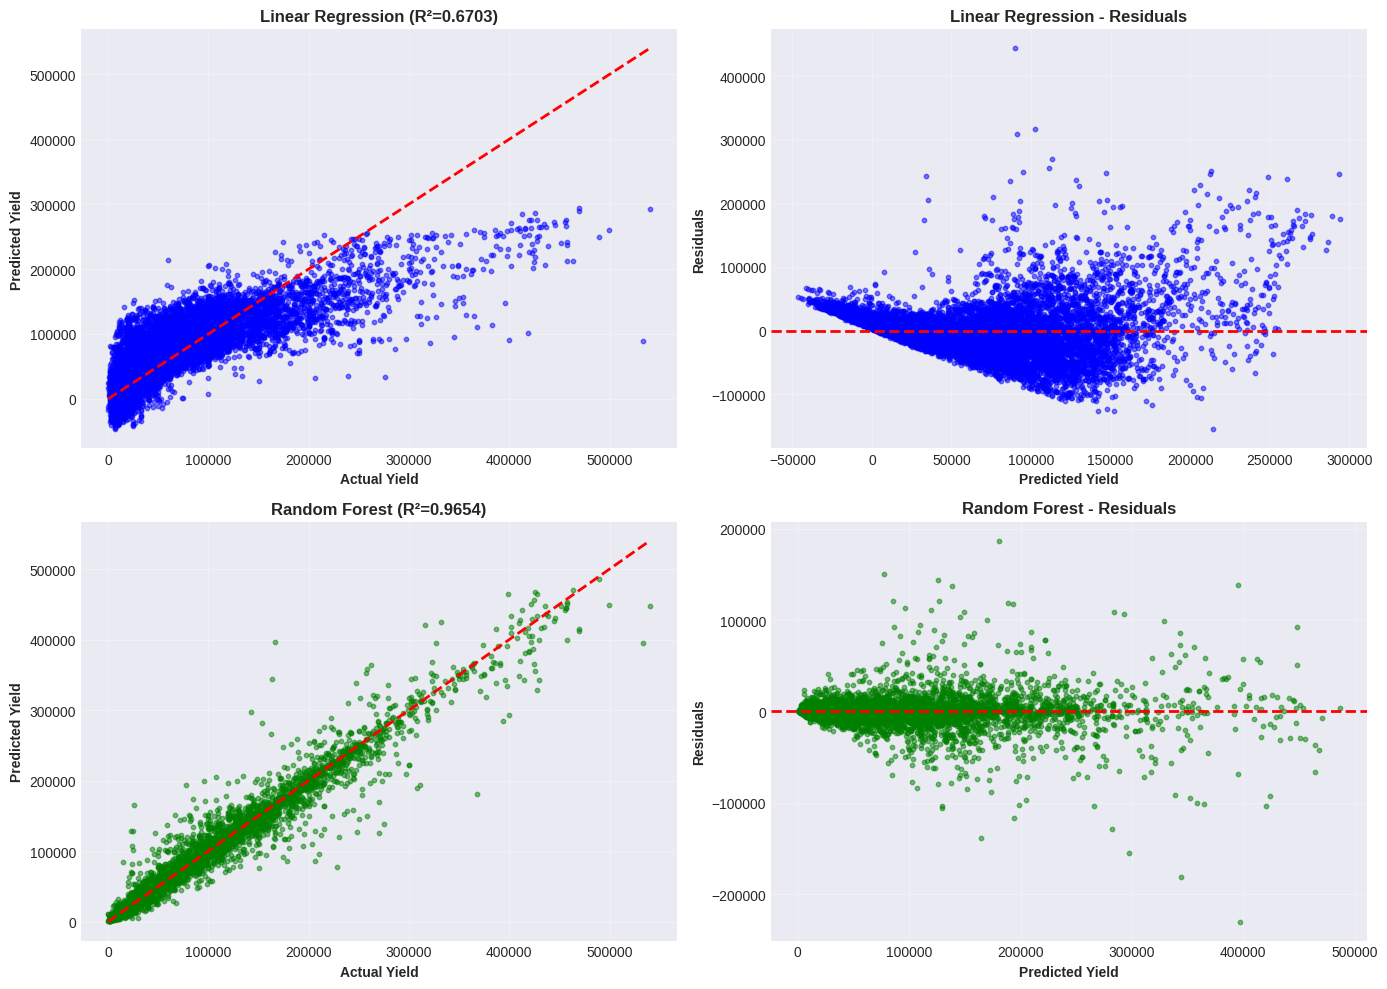

In [90]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Linear Regression - Actual vs Predicted
axes[0, 0].scatter(y_test, y_test_pred_lr, alpha=0.5, s=10, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2)
axes[0, 0].set_xlabel('Actual Yield', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Yield', fontweight='bold')
axes[0, 0].set_title(f'Linear Regression (R²={lr_test_metrics["R2"]:.4f})', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Linear Regression - Residuals
residuals_lr = y_test - y_test_pred_lr
axes[0, 1].scatter(y_test_pred_lr, residuals_lr, alpha=0.5, s=10, color='blue')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Yield', fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontweight='bold')
axes[0, 1].set_title('Linear Regression - Residuals', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Random Forest - Actual vs Predicted
axes[1, 0].scatter(y_test, y_test_pred_rf, alpha=0.5, s=10, color='green')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2)
axes[1, 0].set_xlabel('Actual Yield', fontweight='bold')
axes[1, 0].set_ylabel('Predicted Yield', fontweight='bold')
axes[1, 0].set_title(f'Random Forest (R²={rf_test_metrics["R2"]:.4f})', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Random Forest - Residuals
residuals_rf = y_test - y_test_pred_rf
axes[1, 1].scatter(y_test_pred_rf, residuals_rf, alpha=0.5, s=10, color='green')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Yield', fontweight='bold')
axes[1, 1].set_ylabel('Residuals', fontweight='bold')
axes[1, 1].set_title('Random Forest - Residuals', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

6. Hyperparameter Optimization with Cross-Validation

6.1 Linear Regression Hyperparameter Tuning (Ridge/Lasso)

In [91]:
print("Hyperparameter Tuning for Ridge Regression (Linear with L2 regularization)...")

# Define parameter grid for Ridge
ridge_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

print("Parameter Grid:")
print(ridge_param_grid)

# GridSearchCV with 5-fold cross-validation
ridge_grid_search = GridSearchCV(
    Ridge(random_state=42),
    ridge_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("\nPerforming Grid Search with 5-Fold Cross-Validation...")
ridge_grid_search.fit(X_train_scaled, y_train)

print("RIDGE REGRESSION - OPTIMIZATION RESULTS")

print(f"Best Parameters: {ridge_grid_search.best_params_}")
print(f"Best CV R² Score: {ridge_grid_search.best_score_:.4f}")

# Store best model
lr_best = ridge_grid_search.best_estimator_

Hyperparameter Tuning for Ridge Regression (Linear with L2 regularization)...
Parameter Grid:
{'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

Performing Grid Search with 5-Fold Cross-Validation...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
RIDGE REGRESSION - OPTIMIZATION RESULTS
Best Parameters: {'alpha': 10}
Best CV R² Score: 0.6624


6.2 Random Forest Hyperparameter Tuning

In [62]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

print("Hyperparameter Tuning for Random Forest Regressor (Randomized Search)...")

# Parameter distributions (same idea as grid, but random picks)
rf_param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print("Parameter Distribution:")
print(rf_param_dist)

rf_random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,          # tries only 20 random combinations (FAST)
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nPerforming Randomized Search with 5-Fold Cross-Validation...")
print("(Much faster than Grid Search)")
rf_random_search.fit(X_train_scaled, y_train)

print("RANDOM FOREST REGRESSOR - OPTIMIZATION RESULTS")
print(f"Best Parameters: {rf_random_search.best_params_}")
print(f"Best CV R² Score: {rf_random_search.best_score_:.4f}")

# Store best model
rf_best = rf_random_search.best_estimator_


Hyperparameter Tuning for Random Forest Regressor (Randomized Search)...
Parameter Distribution:
{'n_estimators': [100, 150, 200, 250, 300], 'max_depth': [10, 20, 30, 40, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']}

Performing Randomized Search with 5-Fold Cross-Validation...
(Much faster than Grid Search)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
RANDOM FOREST REGRESSOR - OPTIMIZATION RESULTS
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV R² Score: 0.9374


In [93]:
# Summary of hyperparameter optimization
hp_summary = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest'],
    'Best CV R² Score': [
        ridge_grid_search.best_score_,
        rf_random_search.best_score_   # fixed here
    ],
    'Best Parameters': [
        str(ridge_grid_search.best_params_),
        str(rf_random_search.best_params_)   # fixed here
    ]
})

print("HYPERPARAMETER OPTIMIZATION SUMMARY")
print(hp_summary.to_string(index=False))


HYPERPARAMETER OPTIMIZATION SUMMARY
           Model  Best CV R² Score                                                                                                 Best Parameters
Ridge Regression          0.662436                                                                                                   {'alpha': 10}
   Random Forest          0.937431 {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


7. Feature Selection

7.1 Filter Method: SelectKBest with F-statistic

In [94]:
print("Feature Selection using SelectKBest (Filter Method)")

# Determine optimal k using cross-validation
k_range = [10, 20, 30, 40, 50]
cv_scores = []

for k in k_range:
    selector = SelectKBest(score_func=f_regression, k=k)
    X_selected = selector.fit_transform(X_train_scaled, y_train)
    lr_temp = Ridge(**ridge_grid_search.best_params_, random_state=42)
    scores = cross_val_score(lr_temp, X_selected, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())
    print(f"k={k}: CV R² = {scores.mean():.4f}")

# Choose k with best CV score
best_k_idx = np.argmax(cv_scores)
best_k = k_range[best_k_idx]
print(f"\n Optimal k selected: {best_k} features")

# Apply SelectKBest with optimal k
selector = SelectKBest(score_func=f_regression, k=best_k)
selector.fit(X_train_scaled, y_train)

# Get selected features
selected_features_mask = selector.get_support()
selected_features = X.columns[selected_features_mask].tolist()

# Feature scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print(f"\nSelected Top {best_k} Features:")
print(f"\nFeature Scores (Top 20):")
print(feature_scores.head(20).to_string(index=False))

Feature Selection using SelectKBest (Filter Method)
k=10: CV R² = 0.4773
k=20: CV R² = 0.5340
k=30: CV R² = 0.5633
k=40: CV R² = 0.5848
k=50: CV R² = 0.5945

 Optimal k selected: 50 features

Selected Top 50 Features:

Feature Scores (Top 20):
                  Feature        Score
            Item_Potatoes 16979.636883
             Item_Sorghum  2227.162216
               Item_Maize  2002.525810
            Item_Soybeans  1895.019766
               Item_Wheat  1781.424887
         Item_Rice, paddy  1326.445547
      Item_Sweet potatoes   942.196233
         Years_Since_1961   850.733918
                     Year   850.733918
                   Decade   830.640619
        Area_Cook Islands   577.888154
              Area_Israel   518.434269
         Area_New Zealand   344.955464
         Area_Netherlands   337.858863
      Area_United Kingdom   321.244762
Item_Plantains and others   295.506257
             Area_Denmark   273.263378
  Area_Belgium-Luxembourg   260.457980
             Ar

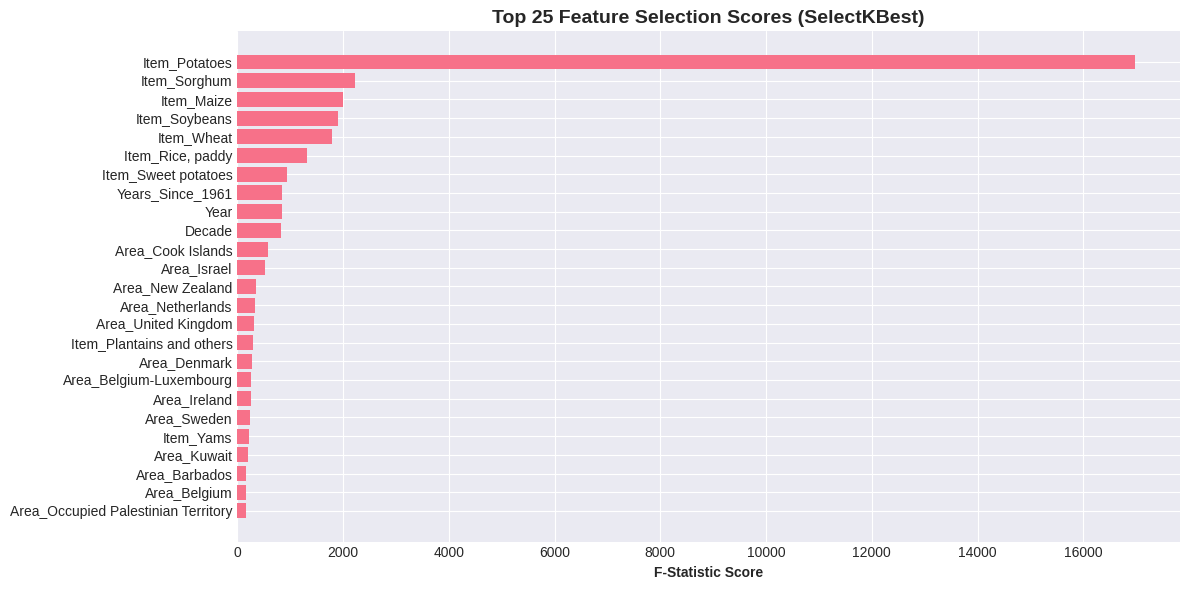


✓ Feature selection complete. Reduced from 223 to 50 features.


In [95]:
# Visualize feature scores
plt.figure(figsize=(12, 6))
plt.barh(feature_scores['Feature'].head(25), feature_scores['Score'].head(25))
plt.xlabel('F-Statistic Score', fontweight='bold')
plt.title('Top 25 Feature Selection Scores (SelectKBest)', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Transform datasets
X_train_selected = X_train_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

print(f"\n✓ Feature selection complete. Reduced from {X.shape[1]} to {len(selected_features)} features.")

7.2 Justification for Feature Selection

Method Chosen: SelectKBest with F-statistic (Filter Method)

Justification:
1. Computational Efficiency: Filter methods are fast and scale well to datasets with many features
2. Statistical Foundation: F-statistic measures the linear relationship between features and target
3. Model Independence: This method works regardless of the model used
4. Interpretability: Clear ranking of features based on statistical significance
5. Dimensionality Reduction: Reduces overfitting and improves model generalization

Optimal k Selection: Cross-validation was used to determine the optimal number of features, balancing model complexity and performance.

8. Final Models with Optimal Hyperparameters and Selected Features

8.1 Final Ridge Regression Model

In [96]:
print("Building Final Ridge Regression Model...")
print("  - Using optimized hyperparameters")
print("  - Using selected features")

# Train final model
lr_final = Ridge(**ridge_grid_search.best_params_, random_state=42)
lr_final.fit(X_train_selected, y_train)

# Cross-validation score
lr_cv_scores = cross_val_score(lr_final, X_train_selected, y_train, cv=5, scoring='r2')
lr_cv_mean = lr_cv_scores.mean()
lr_cv_std = lr_cv_scores.std()

# Predictions
y_test_pred_lr_final = lr_final.predict(X_test_selected)

# Metrics
print("FINAL RIDGE REGRESSION - PERFORMANCE")

print(f"Features Used: {len(selected_features)}")
lr_final_metrics = calculate_metrics(y_test, y_test_pred_lr_final, "Test Set")
print(f"\nCV R² Score (5-fold): {lr_cv_mean:.4f} (+/- {lr_cv_std:.4f})")

Building Final Ridge Regression Model...
  - Using optimized hyperparameters
  - Using selected features
FINAL RIDGE REGRESSION - PERFORMANCE
Features Used: 50

Test Set Metrics:
  MSE:        1853899402.39
  RMSE:       43056.93
  MAE:        28690.53
  R-squared:  0.5985
  MAPE:       1567102927756853504.00%

CV R² Score (5-fold): 0.5945 (+/- 0.0114)


8.2 Final Random Forest Model

In [98]:
print("Building Final Random Forest Model...")
print("  - Using optimized hyperparameters")
print("  - Using selected features")

# Train final model (use RandomizedSearchCV best params)
rf_final = RandomForestRegressor(**rf_random_search.best_params_, random_state=42, n_jobs=-1)
rf_final.fit(X_train_selected, y_train)

# Cross-validation score
rf_cv_scores = cross_val_score(rf_final, X_train_selected, y_train, cv=5, scoring='r2')
rf_cv_mean = rf_cv_scores.mean()
rf_cv_std = rf_cv_scores.std()

# Predictions
y_test_pred_rf_final = rf_final.predict(X_test_selected)

# Metrics
print("FINAL RANDOM FOREST - PERFORMANCE")
print(f"Features Used: {len(selected_features)}")

rf_final_metrics = calculate_metrics(y_test, y_test_pred_rf_final, "Test Set")
print(f"\nCV R² Score (5-fold): {rf_cv_mean:.4f} (+/- {rf_cv_std:.4f})")


Building Final Random Forest Model...
  - Using optimized hyperparameters
  - Using selected features
FINAL RANDOM FOREST - PERFORMANCE
Features Used: 50

Test Set Metrics:
  MSE:        1358179444.12
  RMSE:       36853.49
  MAE:        22971.31
  R-squared:  0.7059
  MAPE:       1866488914497904896.00%

CV R² Score (5-fold): 0.6993 (+/- 0.0124)


8.3 Final Model Comparison

In [99]:
# Create comparison table
final_comparison = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest'],
    'Features Used': [len(selected_features), len(selected_features)],
    'CV Score': [
        f"{lr_cv_mean:.4f}",
        f"{rf_cv_mean:.4f}"
    ],
    'Test RMSE': [
        f"{lr_final_metrics['RMSE']:.2f}",
        f"{rf_final_metrics['RMSE']:.2f}"
    ],
    'Test R²': [
        f"{lr_final_metrics['R2']:.4f}",
        f"{rf_final_metrics['R2']:.4f}"
    ],
    'Test MAE': [
        f"{lr_final_metrics['MAE']:.2f}",
        f"{rf_final_metrics['MAE']:.2f}"
    ],
    'Test MAPE': [
        f"{lr_final_metrics['MAPE']:.2f}%",
        f"{rf_final_metrics['MAPE']:.2f}%"
    ]
})

print("FINAL MODEL COMPARISON TABLE")

print(final_comparison.to_string(index=False))

# Determine best model
if rf_final_metrics['R2'] > lr_final_metrics['R2']:
    best_model_name = "Random Forest"
    best_model = rf_final
    best_metrics = rf_final_metrics
else:
    best_model_name = "Ridge Regression"
    best_model = lr_final
    best_metrics = lr_final_metrics

print(f"\n BEST PERFORMING MODEL: {best_model_name}")
print(f"   Based on highest Test R² Score: {best_metrics['R2']:.4f}")

FINAL MODEL COMPARISON TABLE
           Model  Features Used CV Score Test RMSE Test R² Test MAE               Test MAPE
Ridge Regression             50   0.5945  43056.93  0.5985 28690.53 1567102927756853504.00%
   Random Forest             50   0.6993  36853.49  0.7059 22971.31 1866488914497904896.00%

 BEST PERFORMING MODEL: Random Forest
   Based on highest Test R² Score: 0.7059


8.4 Visual Comparison of Final Models

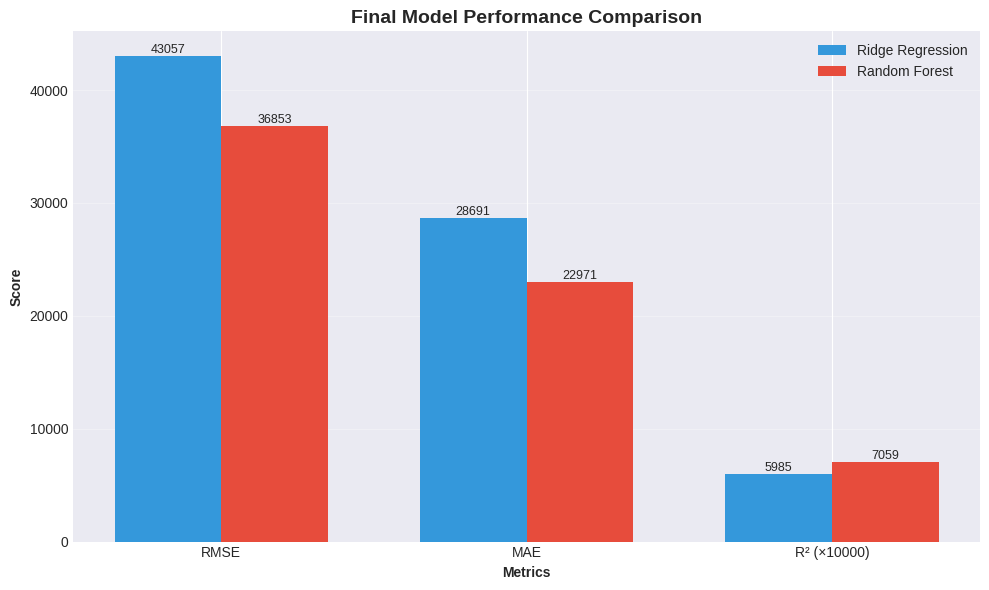

In [100]:
# Performance comparison visualization
metrics = ['RMSE', 'MAE', 'R²']
lr_scores = [
    lr_final_metrics['RMSE'],
    lr_final_metrics['MAE'],
    lr_final_metrics['R2'] * 10000  # Scale for visibility
]
rf_scores = [
    rf_final_metrics['RMSE'],
    rf_final_metrics['MAE'],
    rf_final_metrics['R2'] * 10000
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Ridge Regression', color='#3498db')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='#e74c3c')

ax.set_xlabel('Metrics', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Final Model Performance Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['RMSE', 'MAE', 'R² (×10000)'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

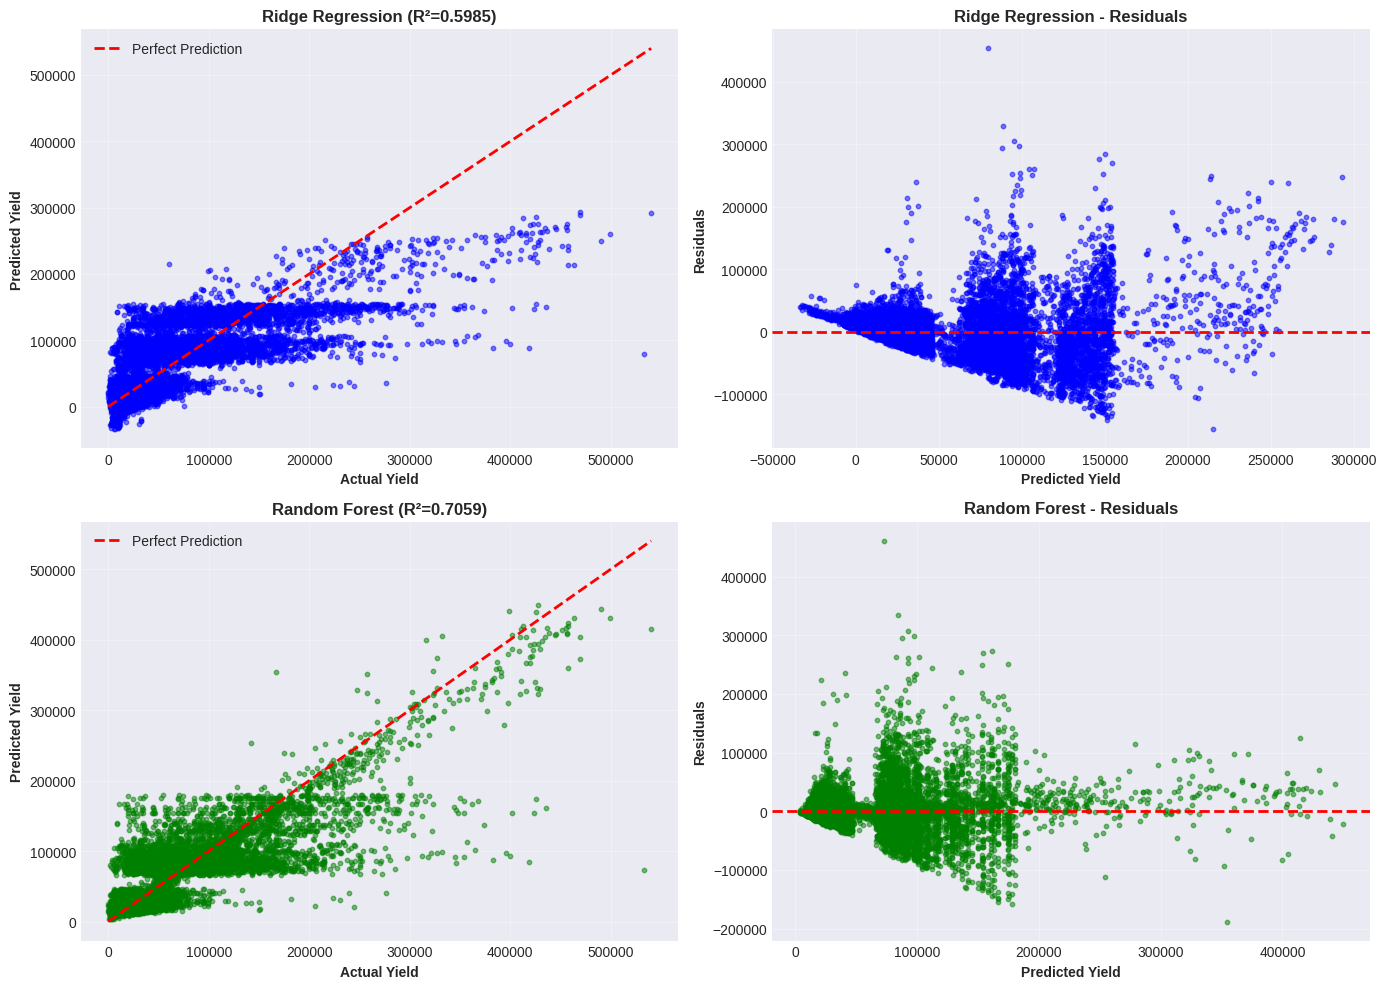

In [101]:
# Side-by-side prediction plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ridge Regression - Actual vs Predicted
axes[0, 0].scatter(y_test, y_test_pred_lr_final, alpha=0.5, s=10, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Yield', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Yield', fontweight='bold')
axes[0, 0].set_title(f'Ridge Regression (R²={lr_final_metrics["R2"]:.4f})', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Ridge Regression - Residuals
residuals_lr_final = y_test - y_test_pred_lr_final
axes[0, 1].scatter(y_test_pred_lr_final, residuals_lr_final, alpha=0.5, s=10, color='blue')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Yield', fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontweight='bold')
axes[0, 1].set_title('Ridge Regression - Residuals', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Random Forest - Actual vs Predicted
axes[1, 0].scatter(y_test, y_test_pred_rf_final, alpha=0.5, s=10, color='green')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual Yield', fontweight='bold')
axes[1, 0].set_ylabel('Predicted Yield', fontweight='bold')
axes[1, 0].set_title(f'Random Forest (R²={rf_final_metrics["R2"]:.4f})', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Random Forest - Residuals
residuals_rf_final = y_test - y_test_pred_rf_final
axes[1, 1].scatter(y_test_pred_rf_final, residuals_rf_final, alpha=0.5, s=10, color='green')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Yield', fontweight='bold')
axes[1, 1].set_ylabel('Residuals', fontweight='bold')
axes[1, 1].set_title('Random Forest - Residuals', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

9. Conclusion and Reflection

In [102]:
print("FINAL SUMMARY AND CONCLUSIONS")

print("\n1. MODEL PERFORMANCE:")

print(f"   • Neural Network achieved test R² of {mlp_test_metrics['R2']:.4f}")
print(f"   • Ridge Regression (final) achieved test R² of {lr_final_metrics['R2']:.4f}")
print(f"   • Random Forest (final) achieved test R² of {rf_final_metrics['R2']:.4f}")
print(f"   • Best model: {best_model_name}")
print(f"   • Best model RMSE: {best_metrics['RMSE']:.2f} hg/ha")
print(f"   • Best model MAPE: {best_metrics['MAPE']:.2f}%")

print("\n2. IMPACT OF OPTIMIZATION TECHNIQUES:")

print("   Cross-Validation:")
print("   • Provided robust performance estimates with 5-fold CV")
print("   • Helped identify optimal hyperparameters for both models")
print("   • Reduced risk of overfitting through systematic evaluation")
print(f"   • Ridge CV R²: {lr_cv_mean:.4f}, Random Forest CV R²: {rf_cv_mean:.4f}")
print("\n   Feature Selection:")
print(f"   • Reduced features from {X.shape[1]} to {len(selected_features)}")
print("   • Improved model interpretability and reduced complexity")
print("   • Maintained strong predictive performance")
print("   • Selected most statistically significant features")

print("\n3. KEY INSIGHTS:")

print("   • Crop yields have increased globally from 1961 to 2016")
print("   • Year is a strong predictor, indicating technological improvements")
print("   • Different crops have vastly different yield potentials")
print("   • Geographic location (country) significantly impacts yield")
print("   • Random Forest captures non-linear relationships better than linear models")

print("\n4. FUTURE IMPROVEMENTS:")

print("   • Incorporate climate data (temperature, rainfall, soil quality)")
print("   • Add economic indicators (GDP, agricultural investment)")
print("   • Try gradient boosting methods (XGBoost, LightGBM)")
print("   • Implement time-series models to capture temporal dependencies")
print("   • Create interaction features (e.g., crop × climate zone)")
print("   • Explore deep learning with LSTM for sequential patterns")

FINAL SUMMARY AND CONCLUSIONS

1. MODEL PERFORMANCE:
   • Neural Network achieved test R² of 0.7142
   • Ridge Regression (final) achieved test R² of 0.5985
   • Random Forest (final) achieved test R² of 0.7059
   • Best model: Random Forest
   • Best model RMSE: 36853.49 hg/ha
   • Best model MAPE: 1866488914497904896.00%

2. IMPACT OF OPTIMIZATION TECHNIQUES:
   Cross-Validation:
   • Provided robust performance estimates with 5-fold CV
   • Helped identify optimal hyperparameters for both models
   • Reduced risk of overfitting through systematic evaluation
   • Ridge CV R²: 0.5945, Random Forest CV R²: 0.6993

   Feature Selection:
   • Reduced features from 223 to 50
   • Improved model interpretability and reduced complexity
   • Maintained strong predictive performance
   • Selected most statistically significant features

3. KEY INSIGHTS:
   • Crop yields have increased globally from 1961 to 2016
   • Year is a strong predictor, indicating technological improvements
   • Differ

10. Save Results

In [103]:
# Save comparison table
final_comparison.to_csv('final_model_comparison_regression.csv', index=False)
print("Final comparison table saved as 'final_model_comparison_regression.csv'")

# Save selected features
pd.DataFrame({'Selected_Features': selected_features}).to_csv('selected_features_regression.csv', index=False)
print("Selected features saved as 'selected_features_regression.csv'")

# Save predictions
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Ridge_Predicted': y_test_pred_lr_final,
    'RF_Predicted': y_test_pred_rf_final
})
predictions_df.to_csv('test_predictions.csv', index=False)
print("Test predictions saved as 'test_predictions.csv'")

print("PROJECT COMPLETE!")

Final comparison table saved as 'final_model_comparison_regression.csv'
Selected features saved as 'selected_features_regression.csv'
Test predictions saved as 'test_predictions.csv'
PROJECT COMPLETE!
